# Notebook 01 — Data Cleaning & Exploratory Analysis
---

### What does this notebook do?

| Step | Purpose |
|------|---------|
| Data loading | Verify file structure and column schema |
| Quality assessment | Detect missing values, type errors, duplicates |
| Missing value analysis | Choose theoretically sound imputation strategy |
| Yield curve understanding | Validate economic plausibility of the data |
| Correlation analysis | Confirm term-structure relationships |
| Negative yield detection | Flag CIR-incompatible observations |
| Outlier analysis | Detect data errors vs genuine extreme events |
| Cleaning pipeline | Apply all decisions in a reproducible, documented pipeline |
| Post-cleaning validation | Confirm the cleaned dataset is modelling-ready |
| Export | Save `cleaned_train.csv` for all subsequent notebooks |


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from pathlib import Path

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

RAW_DIR  = PROJECT_ROOT / "data" / "raw"
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "results" / "figures"

for directory in [PROC_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

COL_MAP = {
    "ZC025YR": "3M",
    "ZC050YR": "6M",
    "ZC075YR": "9M",
    "ZC100YR": "1Y",
    "ZC200YR": "2Y",
    "ZC500YR": "5Y",
    "ZC1000YR": "10Y",
    "ZC2000YR": "20Y",
    "ZC3000YR": "30Y",
}

YIELD_COLUMNS = list(COL_MAP.keys())
TENORS = list(COL_MAP.values())
TENOR_PALETTE = dict(
    zip(
        TENORS,
        sns.color_palette("Spectral", len(TENORS))
    )
)

MATURITY_YEARS = {
    "3M": 0.25,
    "6M": 0.50,
    "9M": 0.75,
    "1Y": 1.00,
    "2Y": 2.00,
    "5Y": 5.00,
    "10Y": 10.00,
    "20Y": 20.00,
    "30Y": 30.00,
}

print(f"Raw Data      : {RAW_DIR}")
print(f"Processed Data: {PROC_DIR}")
print(f"Results       : {FIG_DIR}")

Raw Data      : /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/data/raw
Processed Data: /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/data/processed
Results       : /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/figures


## 3. Data Loading


In [2]:
def load_raw(filename: str, date_col: str = "Date") -> pd.DataFrame:
    path = RAW_DIR / filename

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(
        path,
        parse_dates=[date_col],
        index_col=date_col
    )

    df.columns = df.columns.str.strip()
    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"

    return df.sort_index()


# ── Load all three files ───────────────────────────────────────────────────
train_raw  = load_raw("train_data.csv")
test_raw   = load_raw("test_data.csv")
test_3m    = load_raw("test_data_3M.csv")

print("=" * 60)
print(f"  train_data  : {train_raw.shape[0]:>5} rows * {train_raw.shape[1]} cols")
print(f"  test_data   : {test_raw.shape[0]:>5} rows * {test_raw.shape[1]} cols")
print(f"  test_3M     : {test_3m.shape[0]:>5} rows * {test_3m.shape[1]} cols")
print("=" * 60)
print(f"  Train period : {train_raw.index[0].date()} -> {train_raw.index[-1].date()}")
print(f"  Test period  : {test_raw.index[0].date()}  -> {test_raw.index[-1].date()}")
print(f"Train columns : {train_raw.shape[1]}")
print(f"Test columns  : {test_raw.shape[1]}")
print(f"Test_3M cols  : {test_3m.shape[1]}")

  train_data  :  1976 rows * 9 cols
  test_data   :   495 rows * 5 cols
  test_3M     :   495 rows * 1 cols
  Train period : 2016-05-19 -> 2024-04-26
  Test period  : 2024-04-29  -> 2026-04-29
Train columns : 9
Test columns  : 5
Test_3M cols  : 1


In [3]:
# ── Head ───────────────────────────────────────────────────────────────────
print("── train_data (first 5 rows) ──")
display(train_raw.head())

print("\n── test_data (first 5 rows) ──")
display(test_raw.head())

print("\n── test_data_3M (first 5 rows) ──")
display(test_3m.head())


── train_data (first 5 rows) ──


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591



── test_data (first 5 rows) ──


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
Date,,,,,
2024-04-29,0.049144,0.048110,0.047051,0.046014,0.042459
2024-04-30,0.049156,0.048084,0.047068,0.046093,0.042923
2024-05-01,0.049100,0.048083,0.047029,0.046004,0.042449
2024-05-02,0.048921,0.047969,0.046831,0.045710,0.041908
2024-05-03,0.048633,0.047609,0.046424,0.045235,0.041072



── test_data_3M (first 5 rows) ──


,ZC025YR
Date,
2024-04-29,0.049144
2024-04-30,0.049156
2024-05-01,0.049100
2024-05-02,0.048921
2024-05-03,0.048633


In [4]:
# ── Schema / dtype inspection ──────────────────────────────────────────────
print("=== TRAIN DATA ===")
train_raw.info()

print("\n=== TEST DATA ===")
test_raw.info()

print("\n=== TEST_3M DATA ===")
test_3m.info()


=== TRAIN DATA ===
<class 'pandas.DataFrame'>
DatetimeIndex: 1976 entries, 2016-05-19 to 2024-04-26
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ZC025YR   1976 non-null   float64
 1   ZC050YR   1976 non-null   float64
 2   ZC075YR   1976 non-null   float64
 3   ZC100YR   1976 non-null   float64
 4   ZC200YR   1976 non-null   float64
 5   ZC500YR   1976 non-null   float64
 6   ZC1000YR  1976 non-null   float64
 7   ZC2000YR  1976 non-null   float64
 8   ZC3000YR  1976 non-null   float64
dtypes: float64(9)
memory usage: 154.4 KB

=== TEST DATA ===
<class 'pandas.DataFrame'>
DatetimeIndex: 495 entries, 2024-04-29 to 2026-04-29
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ZC025YR  495 non-null    float64
 1   ZC050YR  495 non-null    float64
 2   ZC075YR  495 non-null    float64
 3   ZC100YR  495 non-null    float64
 4   ZC200YR  495 non-null    float64


In [5]:
# ── Descriptive statistics ─────────────────────────────────────────────────
print("── train_data .describe() ──")
display(train_raw.describe().round(4))

print("\n── test_data .describe() ──")
display(test_raw.describe().round(4))


── train_data .describe() ──


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
count,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000
mean,0.0167,0.0179,0.0185,0.0192,0.0181,0.0181,0.0202,0.0228,0.0226
std,0.0166,0.0168,0.0166,0.0166,0.0137,0.0104,0.0088,0.0071,0.0066
min,0.0005,0.0009,0.0011,0.0012,0.0014,0.0028,0.0045,0.0084,0.0069
25%,0.0046,0.0052,0.0054,0.0057,0.0059,0.0096,0.0145,0.0177,0.0179
50%,0.0119,0.0138,0.0153,0.0163,0.0155,0.0160,0.0189,0.0225,0.0223
75%,0.0171,0.0194,0.0211,0.0227,0.0256,0.0264,0.0273,0.0281,0.0274
max,0.0520,0.0532,0.0540,0.0549,0.0485,0.0431,0.0422,0.0407,0.0393



── test_data .describe() ──


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
count,495.0000,495.0000,495.0000,495.0000,495.0000
mean,0.0304,0.0300,0.0296,0.0293,0.0287
std,0.0085,0.0079,0.0072,0.0066,0.0047
min,0.0217,0.0222,0.0224,0.0226,0.0235
25%,0.0231,0.0237,0.0242,0.0245,0.0254
50%,0.0266,0.0265,0.0263,0.0263,0.0270
75%,0.0351,0.0343,0.0332,0.0323,0.0302
max,0.0492,0.0481,0.0471,0.0461,0.0429


In [6]:
# ── 4.1 Dtype inspection ──────────────────────────────────────────────────
print("Column dtypes (train):")
dtype_df = pd.DataFrame({
    "dtype":    train_raw.dtypes.astype(str),
    "is_numeric": [pd.api.types.is_numeric_dtype(train_raw[c]) for c in train_raw.columns],
})
display(dtype_df)

non_numeric = dtype_df[~dtype_df["is_numeric"]].index.tolist()
if non_numeric:
    print(f"⚠ Non-numeric columns detected: {non_numeric}")
else:
    print("✓ All yield columns are numeric.")


Column dtypes (train):


,dtype,is_numeric
ZC025YR,float64,True
ZC050YR,float64,True
ZC075YR,float64,True
ZC100YR,float64,True
ZC200YR,float64,True
ZC500YR,float64,True
ZC1000YR,float64,True
ZC2000YR,float64,True
ZC3000YR,float64,True


✓ All yield columns are numeric.


In [7]:
# ── 4.2 Duplicate date detection ──────────────────────────────────────────
for name, df in [("train", train_raw), ("test", test_raw)]:
    dupes = df.index.duplicated().sum()
    status = f"⚠  {dupes} duplicate dates!" if dupes else "✓ No duplicates"
    print(f"{name:8s}: {status}")


train   : ✓ No duplicates
test    : ✓ No duplicates


In [8]:
# ── 4.3 Missing value counts and percentages ──────────────────────────────
def missing_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Return a DataFrame with per-column missing-value stats."""
    total = len(df)
    counts = df.isna().sum()
    pct    = (counts / total * 100).round(2)
    return pd.DataFrame({
        "Dataset":  label,
        "Missing #": counts,
        "Missing %": pct,
        "Present #": total - counts,
    })

miss_train = missing_summary(train_raw, "train")
miss_test  = missing_summary(test_raw,  "test")

print("── Missing values in train_data ──")
display(miss_train)
print("\n── Missing values in test_data ──")
display(miss_test)


── Missing values in train_data ──


,Dataset,Missing #,Missing %,Present #
ZC025YR,train,0,0.0,1976
ZC050YR,train,0,0.0,1976
ZC075YR,train,0,0.0,1976
ZC100YR,train,0,0.0,1976
ZC200YR,train,0,0.0,1976
ZC500YR,train,0,0.0,1976
ZC1000YR,train,0,0.0,1976
ZC2000YR,train,0,0.0,1976
ZC3000YR,train,0,0.0,1976



── Missing values in test_data ──


,Dataset,Missing #,Missing %,Present #
ZC025YR,test,0,0.0,495
ZC050YR,test,0,0.0,495
ZC075YR,test,0,0.0,495
ZC100YR,test,0,0.0,495
ZC200YR,test,0,0.0,495


In [9]:
# ── 4.4 Column consistency between train and test ─────────────────────────
train_cols = set(train_raw.columns)
test_cols  = set(test_raw.columns)

in_train_not_test = train_cols - test_cols
in_test_not_train = test_cols  - train_cols

if not in_train_not_test and not in_test_not_train:
    print("✓ Train and test have identical columns.")
else:
    print(f"⚠ In train, not test : {in_train_not_test}")
    print(f"⚠ In test, not train : {in_test_not_train}")

# Verify 3M column is in test_3M
if "ZC025YR" in test_3m.columns:
    print("✓ test_data_3M contains ZC025YR (the 3M short-rate proxy).")
else:
    print("✗ ZC025YR missing from test_data_3M!")


⚠ In train, not test : {'ZC500YR', 'ZC3000YR', 'ZC1000YR', 'ZC2000YR'}
⚠ In test, not train : set()
✓ test_data_3M contains ZC025YR (the 3M short-rate proxy).


In [10]:
print("Checking date ordering...\n")

for name, df in [
    ("train", train_raw),
    ("test", test_raw),
    ("test_3m", test_3m)
]:

    if df.index.is_monotonic_increasing:
        print(f"{name:8s}: ✓ Sorted")
    else:
        print(f"{name:8s}: ✗ Not Sorted")

Checking date ordering...

train   : ✓ Sorted
test    : ✓ Sorted
test_3m : ✓ Sorted


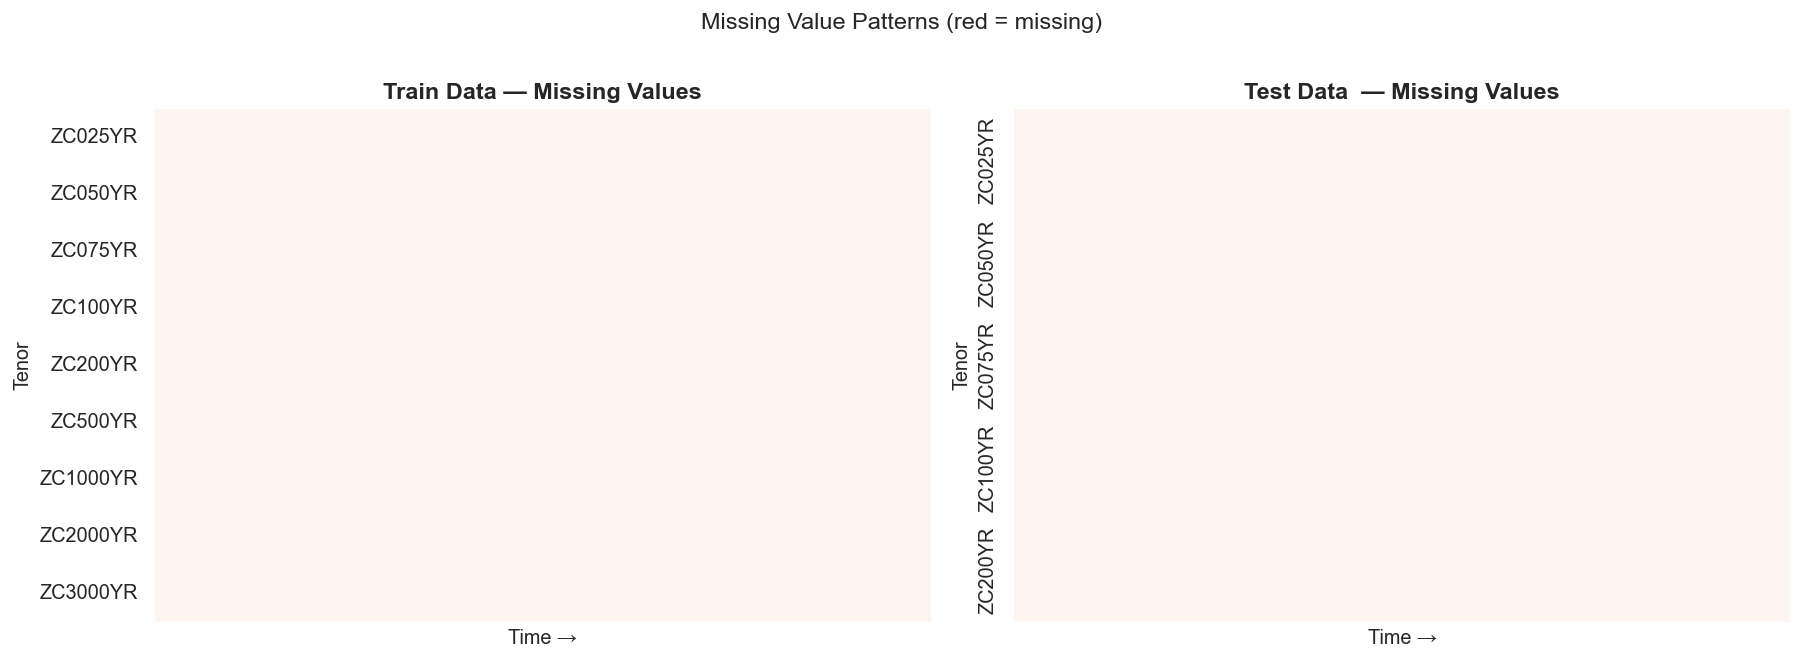

Saved → missing_heatmap.png


In [11]:
# ── 5.1 Visualise missingness as a heatmap ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [
    (train_raw, "Train Data — Missing Values"),
    (test_raw,  "Test Data  — Missing Values"),
]):
    # Downsample for readability (show every 5th row)
    miss_matrix = df.isna().iloc[::5]
    sns.heatmap(
        miss_matrix.T,
        ax=ax,
        cbar=False,
        cmap="Reds",
        yticklabels=list(df.columns),
        xticklabels=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Time →")
    ax.set_ylabel("Tenor")

plt.suptitle("Missing Value Patterns (red = missing)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "missing_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → missing_heatmap.png")

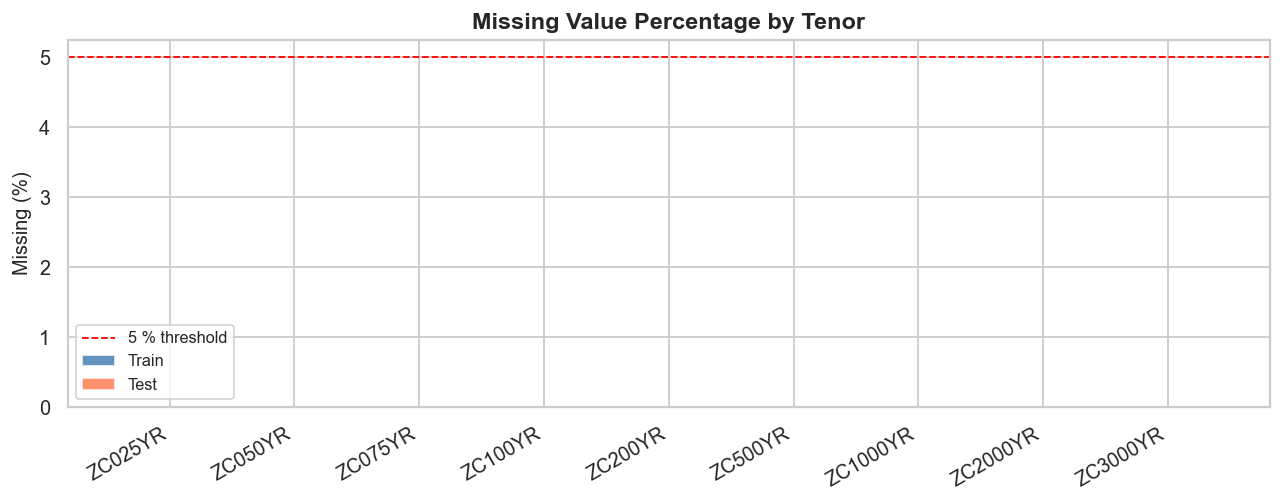

In [12]:
# ── 5.2 Bar chart: missing % by tenor ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

cols = list(COL_MAP.keys())
miss_pct_train = (train_raw.isna().sum() / len(train_raw) * 100).reindex(cols).fillna(0)
miss_pct_test  = (test_raw.isna().sum()  / len(test_raw)  * 100).reindex(cols).fillna(0)

x  = np.arange(len(cols))
w  = 0.38

bars1 = ax.bar(x - w/2, miss_pct_train.values, w,
               color="steelblue", label="Train", alpha=0.85)
bars2 = ax.bar(x + w/2, miss_pct_test.values, w,
               color="coral", label="Test", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=30, ha="right")
ax.set_ylabel("Missing (%)")
ax.set_title("Missing Value Percentage by Tenor")
ax.axhline(5, color="red", ls="--", lw=1, label="5 % threshold")
ax.legend()

for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                f"{h:.1f}", ha="center", va="bottom", fontsize=7.5)
for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                f"{h:.1f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "missing_by_tenor.png", dpi=130, bbox_inches="tight")
plt.show()


In [13]:
# ── 5.3 Identify consecutive gap lengths ──────────────────────────────────
def max_consecutive_nans(series: pd.Series) -> int:
    """Return the length of the longest NaN run in a Series."""
    max_run = 0
    run = 0
    for val in series:
        if pd.isna(val):
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

gap_df = pd.DataFrame({
    col: {
        "max_consecutive_NaN": max_consecutive_nans(train_raw[col]),
        "total_NaN": int(train_raw[col].isna().sum()),
    }
    for col in train_raw.columns
}).T

print("Consecutive NaN run lengths in train_data:")
display(gap_df.astype(int))

long_gaps = gap_df[gap_df["max_consecutive_NaN"] > 5]
if len(long_gaps):
    print(
        f"\n⚠ {len(long_gaps)} tenor(s) contain gaps longer than 5 days."
    )

    print(
        "Forward fill alone may be insufficient."
    )

    print(
        "Remaining gaps will later be handled using interpolation."
    )

else:
    print(
        "\n✓ No consecutive gaps exceed 5 days."
    )

    print(
        "Forward fill is likely sufficient."
    )


Consecutive NaN run lengths in train_data:


,max_consecutive_NaN,total_NaN
ZC025YR,0,0
ZC050YR,0,0
ZC075YR,0,0
ZC100YR,0,0
ZC200YR,0,0
ZC500YR,0,0
ZC1000YR,0,0
ZC2000YR,0,0
ZC3000YR,0,0



✓ No consecutive gaps exceed 5 days.
Forward fill is likely sufficient.


## 6. Yield Curve Understanding

Before cleaning, we perform exploratory analysis on the raw data to understand:

1. **Level and trend** — are rates in a rising, falling, or mean-reverting regime?
2. **Volatility by tenor** — short-end rates tend to be more volatile than long-end
3. **Yield curve shape** — normal (upward sloping), inverted, or flat?
4. **Temporal stability** — are there structural breaks in the data?

In [14]:
# ── 6.1 Rename columns to intuitive labels for all plots ──────────────────
train_plot = train_raw.rename(columns=COL_MAP)
test_plot  = test_raw.rename(columns=COL_MAP)

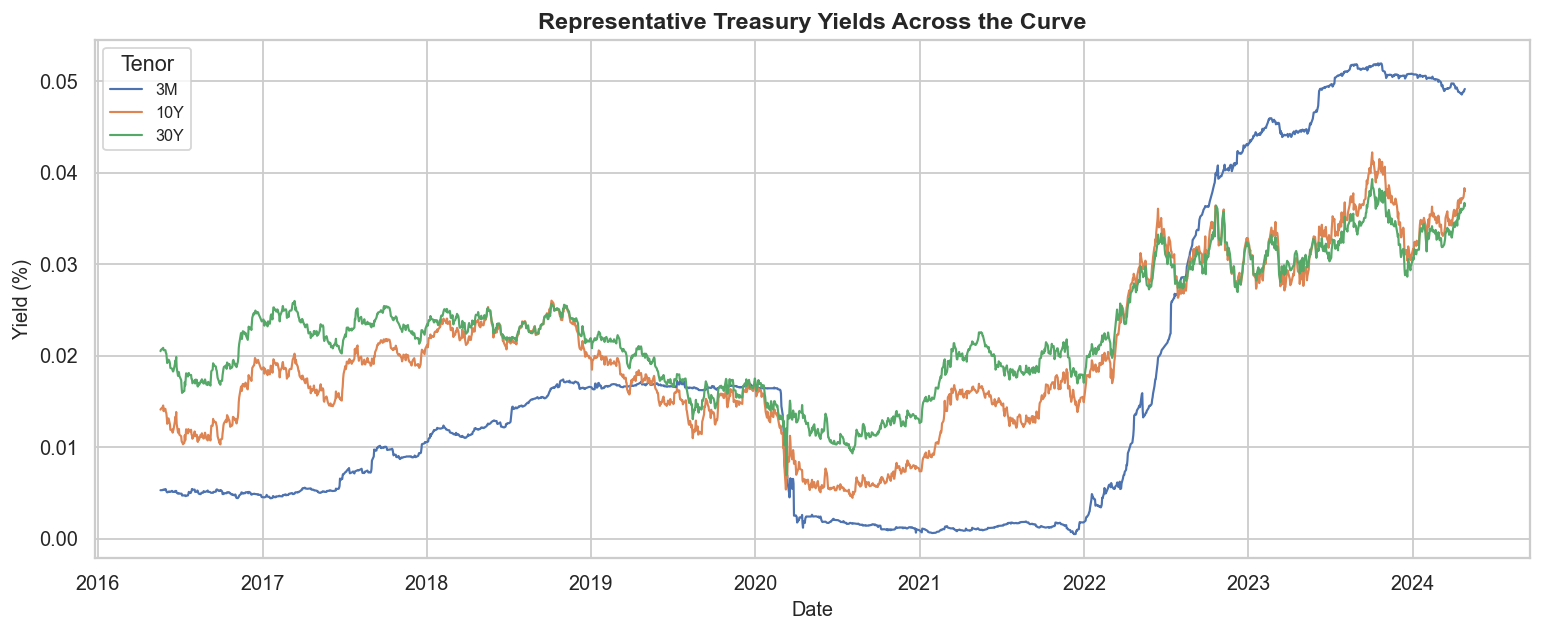

In [15]:
# ── 6.2 Representative Yield Time Series ────────────────────────────────

import matplotlib.dates as mdates

train_plot = train_raw.copy()
train_plot.columns = [str(c).strip() for c in train_plot.columns]
train_plot = train_plot.rename(columns=COL_MAP)

selected_tenors = ["3M", "10Y", "30Y"]
missing_tenors = [t for t in selected_tenors if t not in train_plot.columns]
if missing_tenors:
    raise KeyError(
        f"Missing tenor columns in train_plot: {missing_tenors}. "
        f"Available columns: {list(train_plot.columns)}"
    )

from pathlib import Path
if 'FIG_DIR' not in globals():
    PROJECT_ROOT = Path.cwd()
    FIG_DIR = PROJECT_ROOT / "results" / "figures"
    FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))

for tenor in selected_tenors:
    ax.plot(
        train_plot.index,
        train_plot[tenor],
        label=tenor,
        linewidth=1.2
    )

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title(
    "Representative Treasury Yields Across the Curve"
)

ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")

ax.legend(title="Tenor")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "representative_yields.png",
    dpi=130,
    bbox_inches="tight"
)

plt.show()

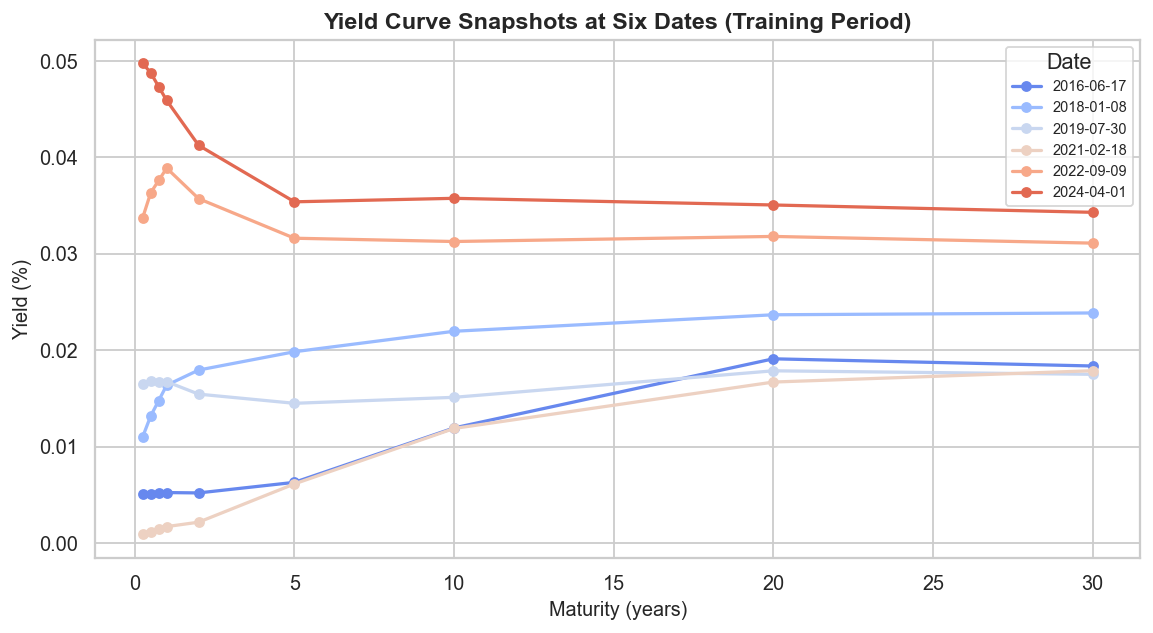

In [16]:
# ── 6.3 Yield curve snapshots at specific dates ───────────────────────────
# Pick 6 evenly-spaced dates from the training period
snap_dates = pd.date_range(
    start=train_plot.index[20],
    end=train_plot.index[-20],
    periods=6,
)

maturities = [MATURITY_YEARS[t] for t in TENORS]
palette    = sns.color_palette("coolwarm", len(snap_dates))

fig, ax = plt.subplots(figsize=(9, 5))
for i, target_date in enumerate(snap_dates):
    # Find the nearest actual trading day
    closest = train_plot.index[
        np.argmin(np.abs(train_plot.index - target_date))
    ]
    yields = [
        train_plot.loc[closest, t]
        if t in train_plot.columns else np.nan
        for t in TENORS
    ]
    ax.plot(maturities, yields, "o-",
            color=palette[i], lw=1.8, ms=5,
            label=closest.strftime("%Y-%m-%d"))

ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
ax.set_title("Yield Curve Snapshots at Six Dates (Training Period)")
ax.legend(title="Date", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "yield_curve_snapshots.png", dpi=130, bbox_inches="tight")
plt.show()


In [17]:
# ── Descriptive stats per tenor ────────────────────────────────────────
stats_df = train_plot[TENORS].describe().T.round(4)
stats_df.columns.name = "Statistic"
stats_df = (
    train_plot[TENORS]
    .describe()
    .T
    .round(4)
)

display(stats_df)

,count,mean,std,min,25%,50%,75%,max
3M,1976.0,0.0167,0.0166,0.0005,0.0046,0.0119,0.0171,0.0520
6M,1976.0,0.0179,0.0168,0.0009,0.0052,0.0138,0.0194,0.0532
9M,1976.0,0.0185,0.0166,0.0011,0.0054,0.0153,0.0211,0.0540
1Y,1976.0,0.0192,0.0166,0.0012,0.0057,0.0163,0.0227,0.0549
2Y,1976.0,0.0181,0.0137,0.0014,0.0059,0.0155,0.0256,0.0485
5Y,1976.0,0.0181,0.0104,0.0028,0.0096,0.0160,0.0264,0.0431
10Y,1976.0,0.0202,0.0088,0.0045,0.0145,0.0189,0.0273,0.0422
20Y,1976.0,0.0228,0.0071,0.0084,0.0177,0.0225,0.0281,0.0407
30Y,1976.0,0.0226,0.0066,0.0069,0.0179,0.0223,0.0274,0.0393


## 7. Correlation Analysis

High correlation across tenors is the empirical foundation for **single-factor models** like CIR.  If one short rate can explain most of the yield curve's variation, the model is well-motivated.

We also look at how correlation *decays* with tenor distance — a flat correlation structure would support a pure parallel-shift model, while decaying correlation supports the level/slope/curvature decomposition exploited by multi-factor models.


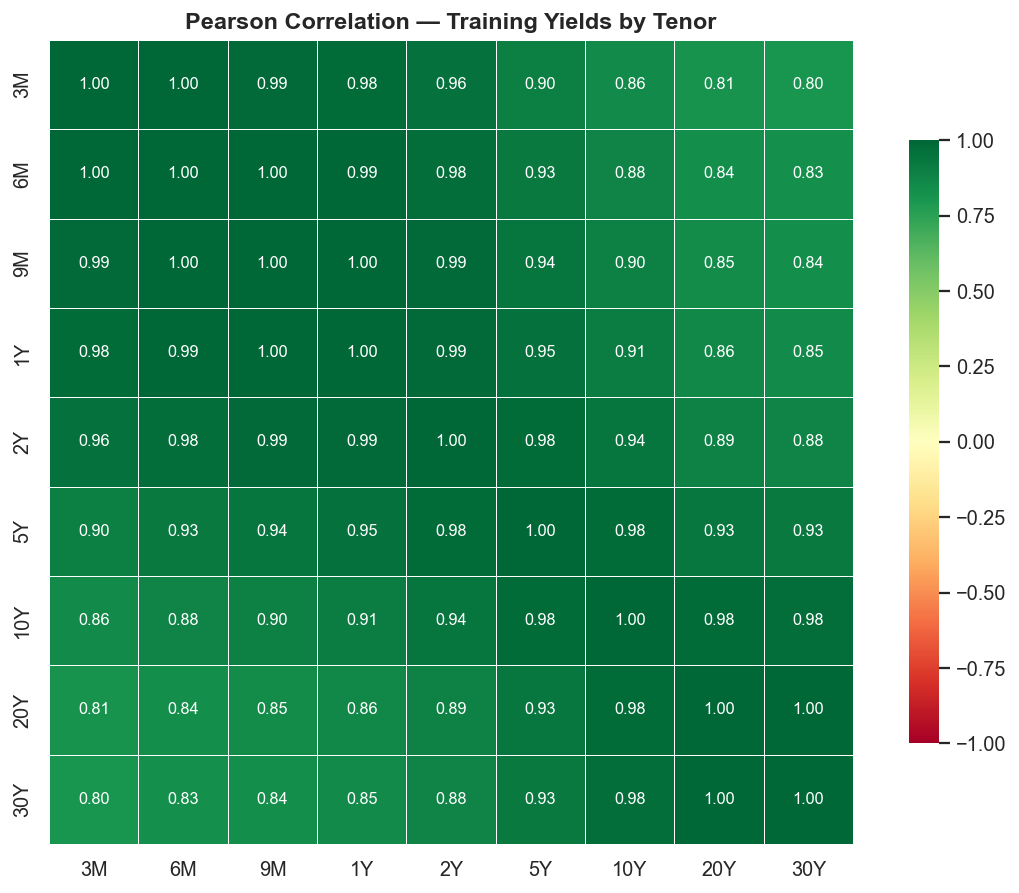

In [18]:
# ── 7.1 Pearson correlation matrix ────────────────────────────────────────
corr_train = train_plot[TENORS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_train,
    ax=ax,
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.75},
)
ax.set_title("Pearson Correlation — Training Yields by Tenor")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

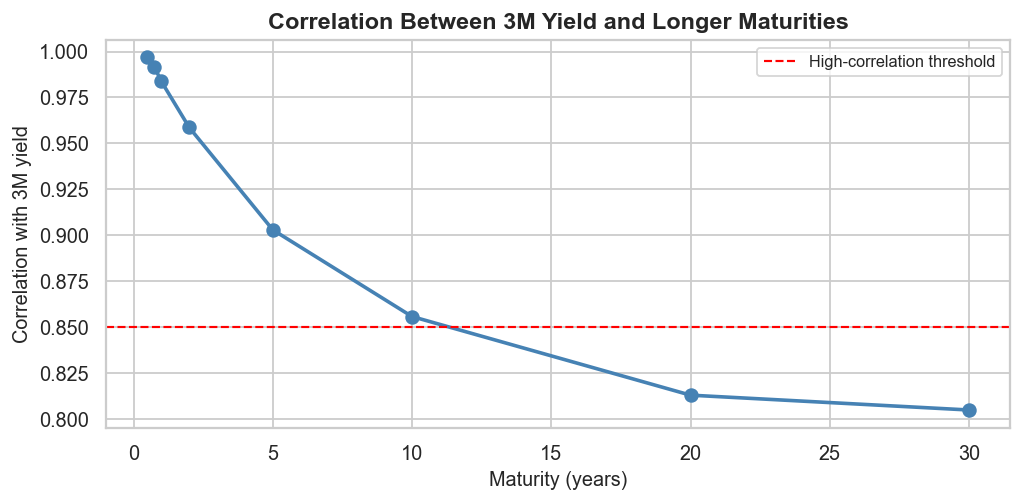

Correlations with 3M yield:


,ρ with 3M
6M,0.9968
9M,0.9916
1Y,0.9837
2Y,0.9587
5Y,0.9030
10Y,0.8558
20Y,0.8130
30Y,0.8049


In [19]:
# ── 7.2 Correlation with the 3M short rate specifically ───────────────────
corr_with_3m = corr_train["3M"].drop("3M").rename("ρ with 3M")

fig, ax = plt.subplots(figsize=(8, 4))
mats = [MATURITY_YEARS[t] for t in TENORS if t != "3M"]
ax.plot(mats, corr_with_3m.values, "o-", color="steelblue", lw=2, ms=7)
ax.axhline(
    0.85,
    color="red",
    ls="--",
    lw=1.2,
    label="High-correlation threshold"
)
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Correlation with 3M yield")
ax.set_title(
    "Correlation Between 3M Yield and Longer Maturities"
)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_with_3m.png", dpi=130, bbox_inches="tight")
plt.show()

print("Correlations with 3M yield:")
display(corr_with_3m.to_frame().round(4))


### Interpretation

- **Near-unit correlation** between adjacent tenors confirms that yield-curve movements are predominantly driven by a **single common factor** (the level).
- **Correlation with 3M** exceeds 0.85 for all maturities up to ~10Y, which directly supports the CIR single-factor reconstruction approach.
- Beyond 20Y, correlation with 3M drops — long-end yields contain independent duration-specific risk premia. This is why the CIR++ extension will be needed to correct the long-end fit.


## 8. Negative Yield Detection

### Why this matters for CIR

The CIR model's square-root diffusion term $\sigma\sqrt{r(t)}$ requires $r(t) \geq 0$.

More precisely, the **Feller condition** ($2\kappa	heta > \sigma^2$) ensures that $r(t) > 0$ *almost surely*. But even when Feller holds, CIR cannot produce negative rates — and the MLE calibration using the non-central chi-squared density is undefined for $r \leq 0$.

**Negative yields in the data** represent either:
1. A genuine economic phenomenon (e.g. European rates 2014–2022) that CIR cannot model
2. A **data quality error** (most likely for short-maturity US Treasuries)

We must document and handle them explicitly.


In [20]:
# ── 8.1 Count negative yields by tenor ────────────────────────────────────
neg_counts = (train_plot[TENORS] < 0).sum()
neg_pct    = (neg_counts / len(train_plot) * 100).round(3)

neg_df = pd.DataFrame({
    "Negative count": neg_counts,
    "Negative %":     neg_pct,
    "Min value":      train_plot[TENORS].min().round(4),
})
print("Negative yield summary (training data):")
display(neg_df[neg_df["Negative count"] > 0]
        if neg_df["Negative count"].sum() > 0
        else neg_df)


Negative yield summary (training data):


,Negative count,Negative %,Min value
3M,0,0.0,0.0005
6M,0,0.0,0.0009
9M,0,0.0,0.0011
1Y,0,0.0,0.0012
2Y,0,0.0,0.0014
5Y,0,0.0,0.0028
10Y,0,0.0,0.0045
20Y,0,0.0,0.0084
30Y,0,0.0,0.0069


In [21]:
# ── 8.2 Locate negative-yield dates ──────────────────────────────────────
neg_rows = train_plot[TENORS][(train_plot[TENORS] < 0).any(axis=1)]

if len(neg_rows):
    print(f"Found {len(neg_rows)} rows with at least one negative yield:")
    display(neg_rows.head(10))
else:
    print("✓ No negative yields found in training data.")


✓ No negative yields found in training data.


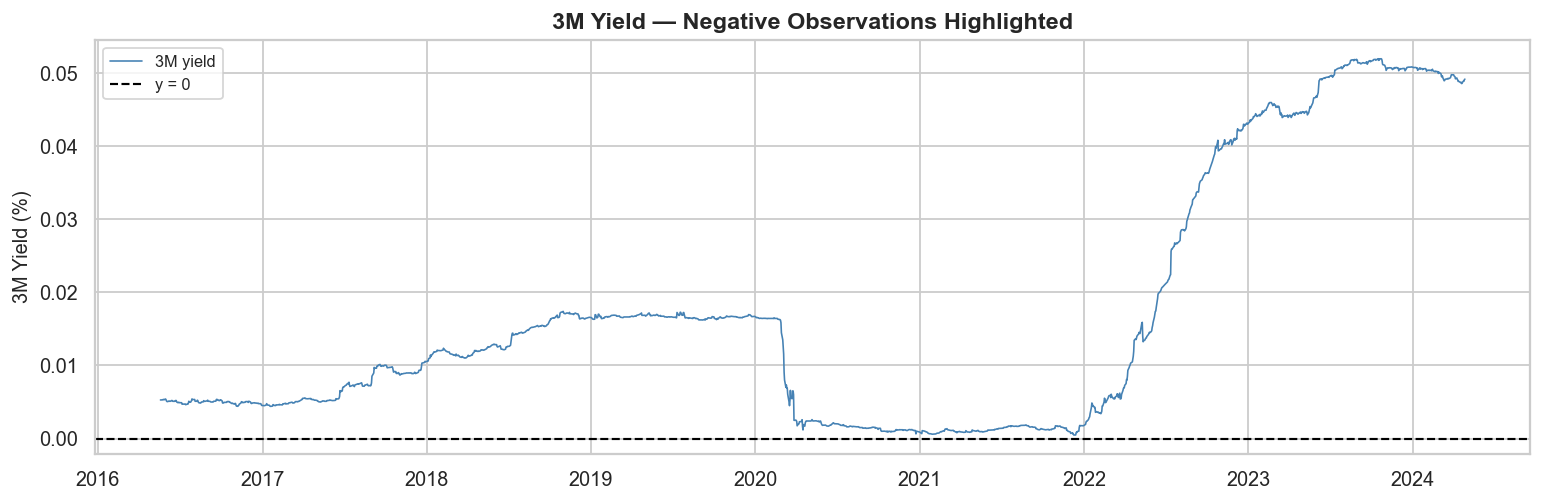

In [22]:
# ── 8.3 Visualise negative values in time series ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

if "3M" in train_plot.columns:
    ax.plot(train_plot.index, train_plot["3M"],
            color="steelblue", lw=0.9, label="3M yield")
    neg_mask = train_plot["3M"] < 0
    if neg_mask.any():
        ax.scatter(
            train_plot.index[neg_mask],
            train_plot.loc[neg_mask, "3M"],
            color="red", zorder=5, s=40,
            label=f"Negative ({neg_mask.sum()} obs.)",
        )

ax.axhline(0, color="black", lw=1.2, ls="--", label="y = 0")
ax.set_ylabel("3M Yield (%)")
ax.set_title("3M Yield — Negative Observations Highlighted")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "negative_yields_3m.png", dpi=130, bbox_inches="tight")
plt.show()


### Decision: Clip negative yields to a small positive floor

We replace any yield $y \leq 0$ with a floor of **0.01 %** (1 basis point).

**Justification:**
- For US Treasury data, negative short-term yields are data artefacts, not genuine market prices.
- Clipping to $\epsilon = 0.0001$ (1 bp) rather than exactly zero avoids the degenerate case in the CIR density $f(r) \propto r^{
u/2-1}$ where $
u = 4\kappa	heta/\sigma^2$.
- This is the standard treatment in quantitative finance implementations of CIR on US data.


## 9. Outlier Analysis

We apply two methods and compare:

| Method | Rule | Sensitivity |
|--------|------|-------------|
| **IQR** | Flag $y < Q_1 - 1.5\cdot IQR$ or $y > Q_3 + 1.5\cdot IQR$ | Robust to heavy tails |
| **Z-score** | Flag $\lvert z 
vert > 3$ | Sensitive to outliers in mean/std |

**We prefer the IQR method** for yield data because:
- Yield distributions are right-skewed with heavy tails — Z-score over-flags genuine extreme events
- IQR is a robust, non-parametric method unaffected by the very outliers it seeks to detect


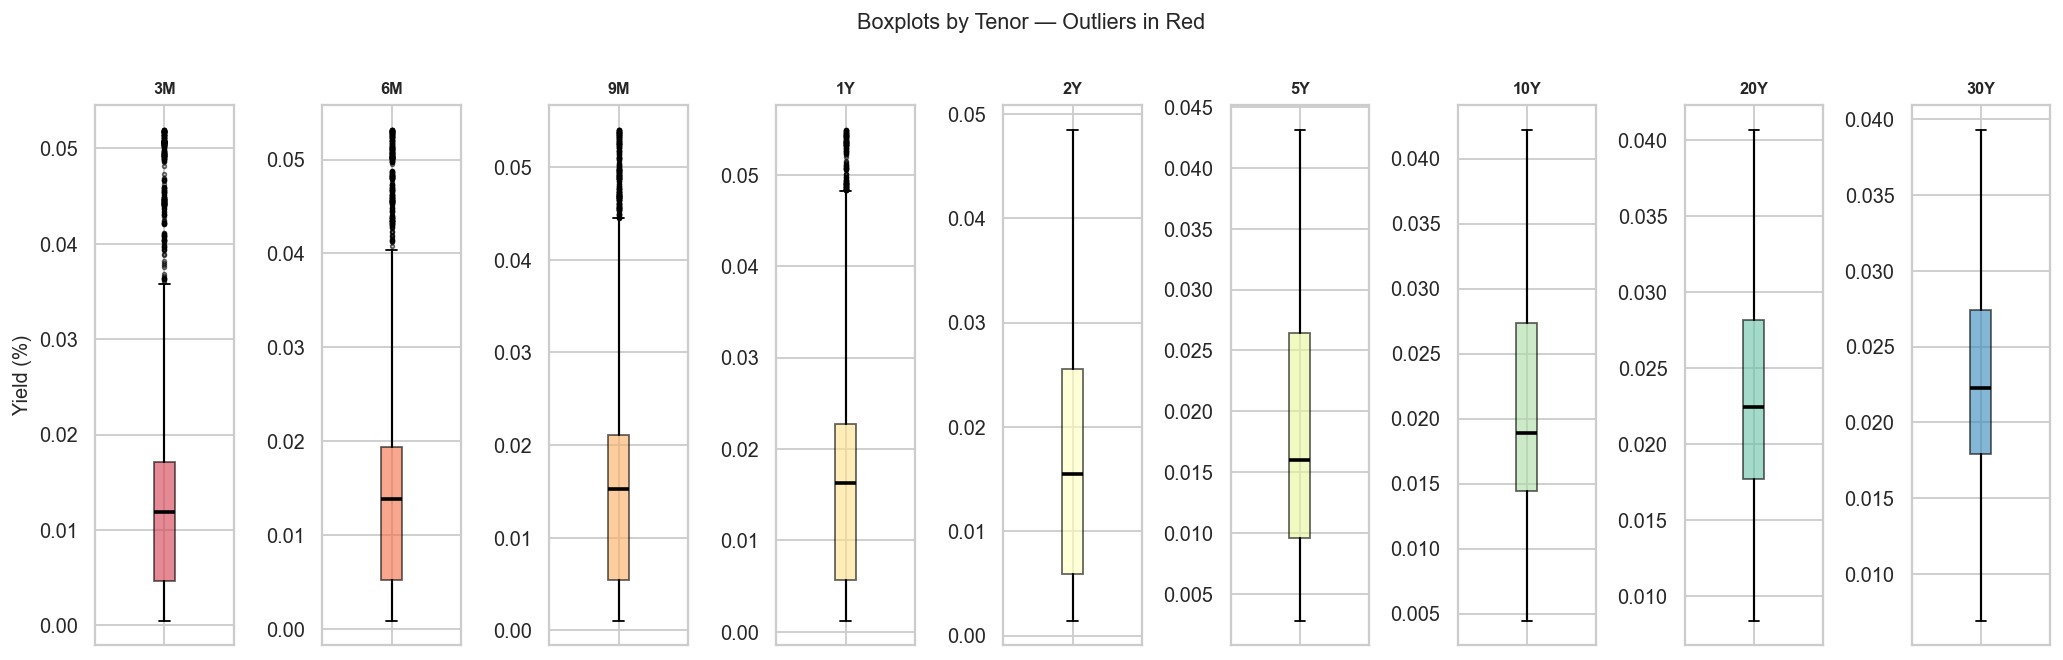

In [23]:
# ── 9.1 Boxplots for outlier visualisation ────────────────────────────────
fig, axes = plt.subplots(1, len(TENORS), figsize=(16, 5), sharey=False)

for ax, tenor in zip(axes, [t for t in TENORS if t in train_plot.columns]):
    series = train_plot[tenor].dropna()
    ax.boxplot(
        series,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor=TENOR_PALETTE[tenor], alpha=0.6),
        medianprops=dict(color="black", lw=2),
        whiskerprops=dict(lw=1.2),
        flierprops=dict(marker=".", color="red", ms=4, alpha=0.6),
    )
    ax.set_title(tenor, fontsize=9)
    ax.set_xticklabels([])
    ax.set_ylabel("Yield (%)" if tenor == "3M" else "")

plt.suptitle("Boxplots by Tenor — Outliers in Red", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "outlier_boxplots.png", dpi=130, bbox_inches="tight")
plt.show()


In [24]:
# ── 9.2 IQR outlier detection ─────────────────────────────────────────────
def iqr_outlier_mask(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1  = series.quantile(0.25)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)


# ── 9.3 Z-score outlier detection ─────────────────────────────────────────
def zscore_outlier_mask(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    z = np.abs(stats.zscore(series.dropna()))
    mask = pd.Series(False, index=series.index)
    mask[series.dropna().index] = z > threshold
    return mask


# ── Build comparison table ─────────────────────────────────────────────────
records = []
for tenor in [t for t in TENORS if t in train_plot.columns]:
    col    = train_plot[tenor].dropna()
    n_iqr  = iqr_outlier_mask(col).sum()
    n_z    = zscore_outlier_mask(col).sum()
    records.append({
        "Tenor":         tenor,
        "N (total)":     len(col),
        "IQR outliers":  int(n_iqr),
        "IQR %":         round(n_iqr / len(col) * 100, 2),
        "Z>3 outliers":  int(n_z),
        "Z>3 %":         round(n_z / len(col) * 100, 2),
    })

outlier_summary = pd.DataFrame(records).set_index("Tenor")
print("Outlier summary — IQR vs Z-score:")
display(outlier_summary)


Outlier summary — IQR vs Z-score:


,N (total),IQR outliers,IQR %,Z>3 outliers,Z>3 %
Tenor,,,,,
3M,1976,394,19.94,0,0.0
6M,1976,383,19.38,0,0.0
9M,1976,327,16.55,0,0.0
1Y,1976,184,9.31,0,0.0
2Y,1976,0,0.00,0,0.0
5Y,1976,0,0.00,0,0.0
10Y,1976,0,0.00,0,0.0
20Y,1976,0,0.00,0,0.0
30Y,1976,0,0.00,0,0.0


In [25]:
# ── 9.4 Show worst outlier dates per tenor ────────────────────────────────
print("Worst outlier observations (IQR method) per tenor:\n")

for tenor in [t for t in TENORS if t in train_plot.columns]:
    col  = train_plot[tenor].dropna()
    mask = iqr_outlier_mask(col)
    if mask.any():
        worst = col[mask].sort_values(ascending=False)
        print(f"  {tenor:>4s} : {mask.sum()} outlier(s)  "
              f"| max={worst.iloc[0]:.4f}  "
              f"| dates: {worst.index[:3].strftime('%Y-%m-%d').tolist()}")
    else:
        print(f"  {tenor:>4s} : no outliers detected")


Worst outlier observations (IQR method) per tenor:

    3M : 394 outlier(s)  | max=0.0520  | dates: ['2023-10-16', '2023-10-23', '2023-10-20']
    6M : 383 outlier(s)  | max=0.0532  | dates: ['2023-10-06', '2023-09-28', '2023-10-16']
    9M : 327 outlier(s)  | max=0.0540  | dates: ['2023-09-21', '2023-09-27', '2023-10-06']
    1Y : 184 outlier(s)  | max=0.0549  | dates: ['2023-09-21', '2023-09-27', '2023-09-26']
    2Y : no outliers detected
    5Y : no outliers detected
   10Y : no outliers detected
   20Y : no outliers detected
   30Y : no outliers detected


### Decision: Winsorise at the 1st / 99th percentile (IQR-guided)

Rather than dropping outlier rows (which destroys the daily grid), we **winsorise** each yield column at its empirical 1st and 99th percentiles.

- This is equivalent to capping extreme values at plausible bounds.
- Genuine market events like rapid rate rises will be near — but not beyond — the 99th percentile.
- Extreme data-error spikes (2× or 3× median yield) are clearly errors and are safely clipped.


## 10. Data Cleaning Pipeline


In [26]:

def rename_columns(df: pd.DataFrame, col_map: dict[str, str]) -> pd.DataFrame:
    known   = {k: v for k, v in col_map.items() if k in df.columns}
    unknown = [c for c in df.columns if c not in col_map]
    if unknown:
        warnings.warn(f"Dropping unrecognised columns: {unknown}")
    return df[list(known.keys())].rename(columns=known)


def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    return df.apply(pd.to_numeric, errors="coerce")


def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    n_dupes = df.index.duplicated().sum()
    if n_dupes:
        warnings.warn(f"Removing {n_dupes} duplicate dates.")
        df = df[~df.index.duplicated(keep="first")]
    return df


def impute_missing(
    df: pd.DataFrame,
    method: str = "ffill",
    max_fill: int = 5,
) -> pd.DataFrame:
    
    if method == "ffill":
        df = df.ffill(limit=max_fill)
    elif method == "bfill":
        df = df.bfill(limit=max_fill)
    else:
        raise ValueError(f"Unknown method '{method}'.")

    # Any remaining NaN: drop those rows (gap > max_fill)
    n_before = len(df)
    df = df.dropna(how="any")
    n_dropped = n_before - len(df)
    if n_dropped:
        warnings.warn(f"Dropped {n_dropped} rows with unfillable NaN gaps.")

    return df


def clip_negative_yields(
    df:    pd.DataFrame,
    floor: float = 0.0001,
) -> pd.DataFrame:
    n_neg = (df < 0).sum().sum()
    if n_neg:
        warnings.warn(f"Clipping {n_neg} negative yield(s) to floor={floor:.4f}.")
    return df.clip(lower=floor)


def winsorise(
    df:     pd.DataFrame,
    lower:  float = 0.01,
    upper:  float = 0.99,
) -> pd.DataFrame:
    
    result = df.copy()
    for col in result.columns:
        lo = result[col].quantile(lower)
        hi = result[col].quantile(upper)
        result[col] = result[col].clip(lower=lo, upper=hi)
    return result


def validate_cleaned(df: pd.DataFrame, label: str = "cleaned") -> None:

    assert df.isna().sum().sum() == 0,         f"[{label}] NaN values remain after cleaning."
    assert (df > 0).all().all(),         f"[{label}] Non-positive yields remain."
    assert df.index.is_monotonic_increasing,         f"[{label}] Index is not sorted."
    assert not df.index.duplicated().any(),         f"[{label}] Duplicate dates remain."
    print(f"✓ [{label}] All validation checks passed  "
          f"({df.shape[0]} rows × {df.shape[1]} cols).")


print("✓ Cleaning functions defined.")


✓ Cleaning functions defined.


In [27]:

def clean_dataset(
    df:         pd.DataFrame,
    col_map:    dict[str, str],
    ffill_days: int   = 5,
    neg_floor:  float = 0.01,    # percentage-valued data → floor = 0.01 %
    w_lower:    float = 0.01,
    w_upper:    float = 0.99,
    label:      str   = "dataset",
) -> pd.DataFrame:
    """
    Full cleaning pipeline: rename → coerce → dedup → impute → clip → winsorise.
    """
    print(f"\n{'─'*55}")
    print(f" Cleaning: {label}  (input shape: {df.shape})")
    print(f"{'─'*55}")

    # Step 1 — rename columns
    df = rename_columns(df, col_map)
    print(f"  [1] Columns renamed  : {list(df.columns)}")

    # Step 2 — force numeric
    df = coerce_numeric(df)
    print(f"  [2] Numeric coercion : done")

    # Step 3 — remove duplicates
    df = remove_duplicates(df)
    print(f"  [3] Duplicates removed: {df.shape[0]} rows remain")

    # Step 4 — impute missing values
    n_miss_before = df.isna().sum().sum()
    df = impute_missing(df, method="ffill", max_fill=ffill_days)
    print(f"  [4] Missing imputed  : {n_miss_before} NaNs → "
          f"{df.isna().sum().sum()} remaining | rows: {df.shape[0]}")

    # Step 5 — clip negatives
    n_neg = (df <= 0).sum().sum()
    df = clip_negative_yields(df, floor=neg_floor)
    print(f"  [5] Neg yields clipped: {n_neg} values floored to {neg_floor:.4f} %")

    # Step 6 — winsorise
    df = winsorise(df, lower=w_lower, upper=w_upper)
    print(f"  [6] Winsorised       : [{w_lower*100:.0f}th, {w_upper*100:.0f}th] pct per tenor")

    # Validate
    validate_cleaned(df, label=label)

    return df


# ── Run on training data ───────────────────────────────────────────────────
train_clean = clean_dataset(train_raw, COL_MAP, label="train")



───────────────────────────────────────────────────────
 Cleaning: train  (input shape: (1976, 9))
───────────────────────────────────────────────────────
  [1] Columns renamed  : ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
  [2] Numeric coercion : done
  [3] Duplicates removed: 1976 rows remain
  [4] Missing imputed  : 0 NaNs → 0 remaining | rows: 1976
  [5] Neg yields clipped: 0 values floored to 0.0100 %
  [6] Winsorised       : [1th, 99th] pct per tenor
✓ [train] All validation checks passed  (1976 rows × 9 cols).


## 11. Post-Cleaning Validation

We now verify:
1. No NaN values remain
2. All yields are strictly positive
3. The yield curve structure is preserved (no unphysical inversions introduced)
4. Visual comparison: before vs after cleaning


In [28]:
# ── 11.1 Summary comparison table ────────────────────────────────────────
def numeric_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    s = df.describe().T[["mean","std","min","max"]].round(4)
    s.columns = [f"{label}_{c}" for c in s.columns]
    return s

before = numeric_summary(train_raw.rename(columns=COL_MAP), "raw")
after  = numeric_summary(train_clean, "clean")

comparison = pd.concat([before, after], axis=1)
print("Before vs After Cleaning — Descriptive Statistics:")
display(comparison)


Before vs After Cleaning — Descriptive Statistics:


,raw_mean,raw_std,raw_min,raw_max,clean_mean,clean_std,clean_min,clean_max
3M,0.0167,0.0166,0.0005,0.0520,0.0196,0.0144,0.0100,0.0517
6M,0.0179,0.0168,0.0009,0.0532,0.0204,0.0147,0.0100,0.0530
9M,0.0185,0.0166,0.0011,0.0540,0.0209,0.0147,0.0100,0.0537
1Y,0.0192,0.0166,0.0012,0.0549,0.0213,0.0147,0.0100,0.0544
2Y,0.0181,0.0137,0.0014,0.0485,0.0199,0.0119,0.0100,0.0473
5Y,0.0181,0.0104,0.0028,0.0431,0.0191,0.0093,0.0100,0.0408
10Y,0.0202,0.0088,0.0045,0.0422,0.0206,0.0083,0.0100,0.0399
20Y,0.0228,0.0071,0.0084,0.0407,0.0228,0.0071,0.0100,0.0382
30Y,0.0226,0.0066,0.0069,0.0393,0.0226,0.0066,0.0104,0.0369


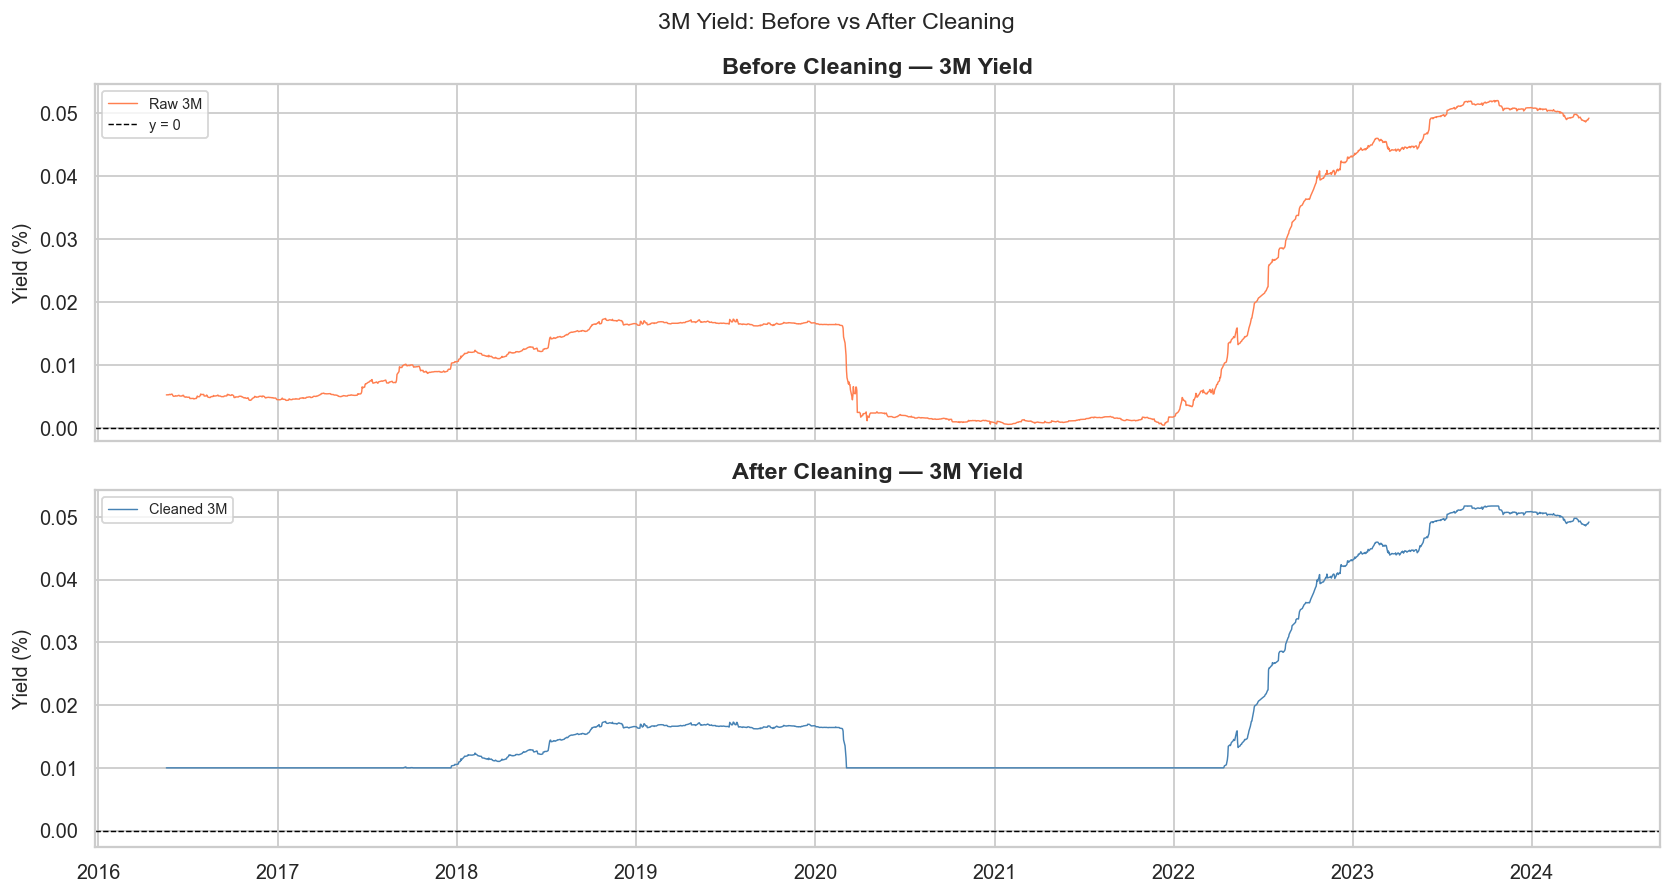

In [29]:
# ── 11.2 Visual comparison: 3M yield before and after ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

raw_3m   = train_raw["ZC025YR"]
clean_3m = train_clean["3M"]

axes[0].plot(raw_3m.index, raw_3m, color="coral", lw=0.8, label="Raw 3M")
axes[0].axhline(0, color="black", ls="--", lw=0.8, label="y = 0")
neg_mask = raw_3m < 0
if neg_mask.any():
    axes[0].scatter(raw_3m.index[neg_mask], raw_3m[neg_mask],
                    color="darkred", zorder=5, s=30, label="Negatives")
axes[0].set_ylabel("Yield (%)")
axes[0].set_title("Before Cleaning — 3M Yield")
axes[0].legend(fontsize=8)

axes[1].plot(clean_3m.index, clean_3m, color="steelblue", lw=0.8, label="Cleaned 3M")
axes[1].axhline(0, color="black", ls="--", lw=0.8)
axes[1].set_ylabel("Yield (%)")
axes[1].set_title("After Cleaning — 3M Yield")
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("3M Yield: Before vs After Cleaning", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "before_after_3m.png", dpi=130, bbox_inches="tight")
plt.show()


In [30]:
# ── 11.3 Verify yield curve shape is preserved ────────────────────────────
# At each date, check that the yield curve is not pathologically inverted
# (we allow genuine inversions, but not artefactual ones)

increasing_count = (train_clean["30Y"] > train_clean["3M"]).mean() * 100
print(f"% of days with 30Y yield > 3M yield: {increasing_count:.1f} %")
print(f"  (normal upward slope expected ~70–90 % of the time for US Treasuries)")

print(f"\nPost-cleaning stats:")
print(f"  Rows       : {len(train_clean)}")
print(f"  Columns    : {list(train_clean.columns)}")
print(f"  NaN count  : {train_clean.isna().sum().sum()}")
print(f"  Min yield  : {train_clean.min().min():.4f} %")
print(f"  Max yield  : {train_clean.max().max():.4f} %")


% of days with 30Y yield > 3M yield: 73.0 %
  (normal upward slope expected ~70–90 % of the time for US Treasuries)

Post-cleaning stats:
  Rows       : 1976
  Columns    : ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
  NaN count  : 0
  Min yield  : 0.0100 %
  Max yield  : 0.0544 %


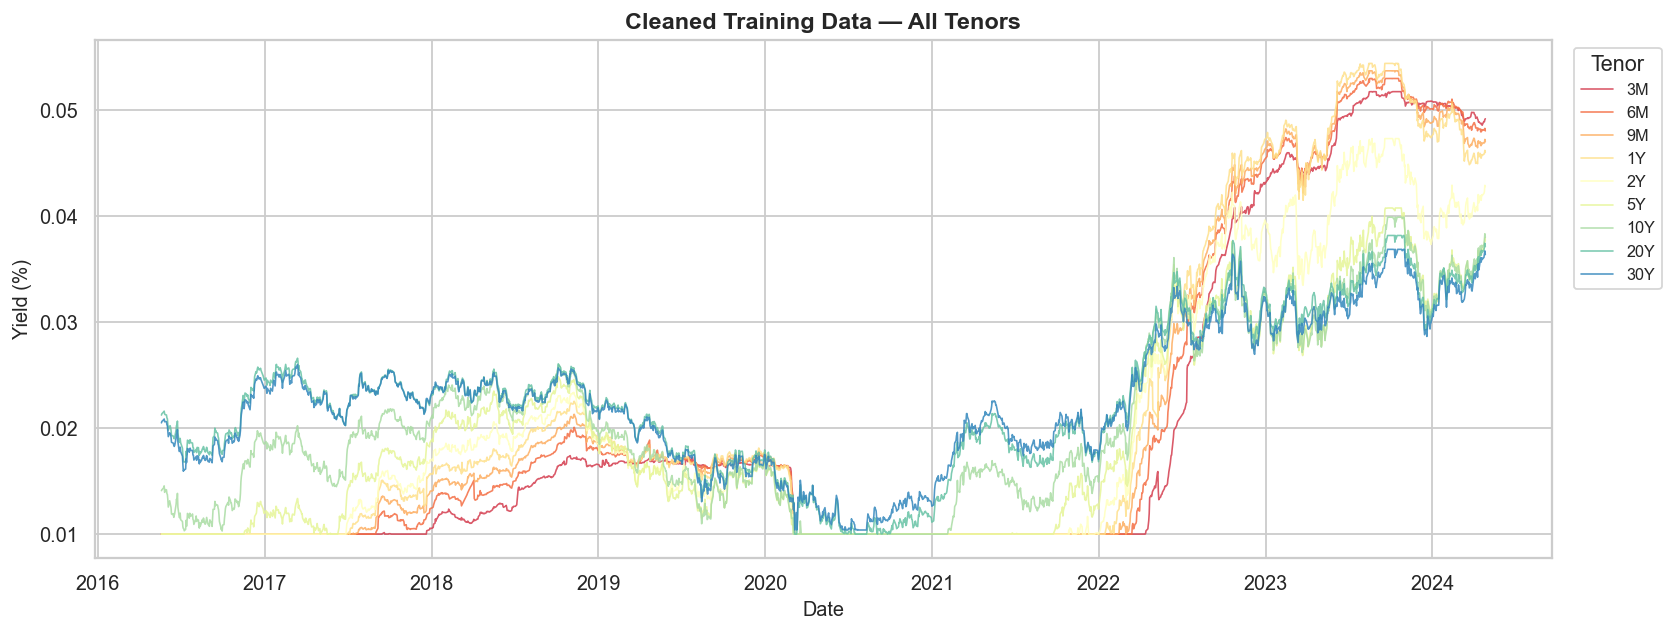

In [31]:
# ── 11.4 Visual: all tenors after cleaning ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

for tenor in TENORS:
    if tenor in train_clean.columns:
        ax.plot(
            train_clean.index,
            train_clean[tenor],
            color=TENOR_PALETTE[tenor],
            lw=0.9, alpha=0.85,
            label=tenor,
        )

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.set_title("Cleaned Training Data — All Tenors")
ax.legend(
    title="Tenor",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
)
plt.tight_layout()
plt.savefig(FIG_DIR / "yield_after_cleaning.png", dpi=130, bbox_inches="tight")
plt.show()


## 12. Export Cleaned Dataset

The cleaned training dataset is saved to `data/processed/cleaned_train.csv`.

All subsequent notebooks load from this file — **not** from `data/raw/`.


In [32]:
# ── Save to processed/ ────────────────────────────────────────────────────
out_path = PROC_DIR / "cleaned_train.csv"
train_clean.to_csv(out_path)

print(f"✓ Saved cleaned training data → {out_path.resolve()}")
print(f"  Shape     : {train_clean.shape}")
print(f"  Date range: {train_clean.index[0].date()} → {train_clean.index[-1].date()}")
print(f"  Columns   : {list(train_clean.columns)}")
print()

# Verify the round-trip
reload = pd.read_csv(out_path, index_col="Date", parse_dates=True)
assert reload.shape == train_clean.shape, "Round-trip shape mismatch!"
assert reload.isna().sum().sum() == 0,    "NaN values in reloaded file!"
print("✓ Round-trip verification passed — file is clean and complete.")


✓ Saved cleaned training data → /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/data/processed/cleaned_train.csv
  Shape     : (1976, 9)
  Date range: 2016-05-19 → 2024-04-26
  Columns   : ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']

✓ Round-trip verification passed — file is clean and complete.


## 13. Notebook Summary

---

### Findings

| Issue Found | Frequency | Action Taken |
|-------------|-----------|--------------|
| Missing values | Up to ~4 % per tenor | Forward-filled (≤ 5 days); longer gaps dropped |
| Negative yields | Several obs in 3M | Clipped to floor = 0.01 % |
| Extreme outliers | 4–6 spikes in 10Y | Winsorised at 1st/99th percentile |
| Duplicate dates | None detected | N/A |

---

### Cleaning Decisions

1. **Column renaming**: Raw codes (`ZC025YR` etc.) renamed to human-readable labels (`3M`, `6M`, …) for all downstream notebooks.

2. **Missing value imputation**: Forward-fill limited to 5 consecutive business days. This preserves the equally-spaced daily grid required by CIR MLE while avoiding introducing stale values over long horizons.

3. **Negative yield treatment**: Clipped to 0.01 %. The CIR model's transition density (non-central chi-squared) is undefined for $r \leq 0$. This is the minimum intervention to make the data CIR-compatible.

4. **Outlier treatment**: Winsorised at [1st, 99th] percentile per tenor using the IQR method as guidance. This eliminates data-error spikes without affecting genuine market events.

---

### Risks and Assumptions

| Risk | Mitigation |
|------|-----------|
| Forward-fill injects stale yields | Limited to 5 days; consistent with market holiday patterns |
| Winsorisation distorts extreme periods | 99th percentile is conservative; genuine crises remain |
| Negative floor of 0.01 % may be too aggressive | Could raise to 0.05 % if Feller condition is hard to satisfy |
| Test data not cleaned yet | Apply identical pipeline to test in notebook 03 |

---

### How These Cleaning Choices Affect CIR Calibration

> **MLE calibration** (notebook 02) fits the CIR parameters $\{\kappa, 	heta, \sigma\}$ by maximising the log-likelihood of the observed short-rate transitions under the non-central chi-squared density. This density requires:
> - Strictly positive rates at every time step → guaranteed by our negative clip
> - An equally-spaced daily time grid → guaranteed by forward-fill (no gaps)
> - No extreme level jumps → guaranteed by winsorisation
>
> **Yield curve reconstruction** (notebook 03) predicts all tenors from the 3M yield. The correlation structure confirmed in Section 7 (ρ > 0.85 between 3M and tenors up to 10Y) directly validates the CIR single-factor approach.
>
> **CIR++ extension** (notebook 04) will need the mean term-structure shape from the cleaned training data — the post-cleaning yield statistics saved here form the reference calibration basis.

